# Transfer-function Bode plotter

Type a transfer function `H(s)` as a Python expression in **`s`** (the Laplace variable, `s = j*w`, `w` in rad/s).
The x-axis is **frequency in Hz**. Call **`bode("...")`** to plot it inline with crossover / phase-margin / gain-margin.

**Hz-based helpers** (so you don't have to write `2*pi*f` everywhere):

| helper | meaning |
|---|---|
| `P(f)` | pole at `f` Hz = `1/(1+s/(2*pi*f))` |
| `Z(f)` | zero at `f` Hz = `1+s/(2*pi*f)` |
| `I(f0)` | integrator, 0 dB at `f0` Hz = `2*pi*f0/s` |
| `Diff(f0)` | differentiator = `s/(2*pi*f0)` |
| `P2(f0,Q)` / `Z2(f0,Q)` | complex pole / zero pair at `f0` Hz, quality `Q` |
| `delay(td)` | time delay `td` seconds = `exp(-s*td)` |

also available: `s, w, j, pi, sqrt, exp, abs, log10, ...`

**Examples**

```python
bode("100*I(16e3)*Z(159e3)*P(909)*P(1.6e3)")     # an LDO-type loop gain
bode("1000/(1+s/6.28e3)/(1+s/6.28e5)")           # two real poles (rad/s form)
bode("50*P2(1e3, 0.5)")                          # resonant pole pair
bode(["I(16e3)*P(1.6e3)", "I(16e3)*P(20e3)"])    # overlay several
```
Run the setup cell once, then edit any `bode(...)` cell and re-run.


In [19]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def _ns(f):
    w = 2*np.pi*f; s = 1j*w
    return {"__builtins__": {},
            "s": s, "w": w, "j": 1j, "pi": np.pi, "e": np.e,
            "sqrt": np.sqrt, "exp": np.exp, "log": np.log, "log10": np.log10,
            "sin": np.sin, "cos": np.cos, "tan": np.tan, "abs": np.abs,
            "real": np.real, "imag": np.imag, "conj": np.conj,
            "P":    lambda f0: 1/(1+s/(2*np.pi*f0)),
            "Z":    lambda f0: (1+s/(2*np.pi*f0)),
            "I":    lambda f0: (2*np.pi*f0)/s,
            "Diff": lambda f0: s/(2*np.pi*f0),
            "P2":   lambda f0, Q: 1/(1+s/(2*np.pi*f0*Q)+(s/(2*np.pi*f0))**2),
            "Z2":   lambda f0, Q: (1+s/(2*np.pi*f0*Q)+(s/(2*np.pi*f0))**2),
            "delay": lambda td: np.exp(-s*td),
            "pole": lambda f0: 1/(1+s/(2*np.pi*f0)),
            "zero": lambda f0: (1+s/(2*np.pi*f0)),
            "integ": lambda f0: (2*np.pi*f0)/s}

def _margins(f, H):
    mag = np.abs(H); ph = np.unwrap(np.angle(H))*180/np.pi
    fc = pm = f180 = gm = None
    k = np.where(np.diff(np.sign(mag-1)) != 0)[0]
    if len(k):
        i = k[0]
        fc = np.exp(np.interp(0, [np.log(mag[i+1]), np.log(mag[i])], [np.log(f[i+1]), np.log(f[i])]))
        pm = 180 + np.interp(np.log(fc), np.log(f), ph)
    k = np.where(np.diff(np.sign(ph+180)) != 0)[0]
    if len(k):
        i = k[0]
        f180 = np.exp(np.interp(-180, [ph[i+1], ph[i]], [np.log(f[i+1]), np.log(f[i])]))
        gm = -20*np.log10(np.exp(np.interp(np.log(f180), np.log(f), np.log(mag))))
    return fc, pm, f180, gm

def bode(exprs, fmin=0.1, fmax=1e7, n=4000):
    """Plot Bode of one transfer-function string, or a list of them (overlaid)."""
    if isinstance(exprs, str): exprs = [exprs]
    f = np.logspace(np.log10(fmin), np.log10(fmax), n)
    fig, (am, ap) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
    for expr in exprs:
        H = np.asarray(eval(expr, _ns(f)), dtype=complex) * np.ones_like(f)
        am.semilogx(f, 20*np.log10(np.abs(H)), label=expr)
        ap.semilogx(f, np.unwrap(np.angle(H))*180/np.pi, label=expr)
        fc, pm, f180, gm = _margins(f, H)
        s = f"{expr}\n"
        s += f"   crossover {fc:.3g} Hz, PM {pm:+.1f} deg" if fc else "   no 0 dB crossover"
        if gm is not None: s += f"  |  -180 deg at {f180:.3g} Hz, GM {gm:+.1f} dB"
        print(s)
    am.axhline(0, color="k", lw=.8); ap.axhline(-180, color="r", ls="--", lw=.8)
    am.set_ylabel("magnitude [dB]"); am.grid(True, which="both", alpha=.3)
    ap.set_ylabel("phase [deg]"); ap.set_xlabel("frequency [Hz]"); ap.grid(True, which="both", alpha=.3)
    if len(exprs) > 1: am.legend(fontsize=8)
    plt.tight_layout(); plt.show()

print("ready - call bode(\"...\")")

ready - call bode("...")


(s+1)/s
   crossover 6.14e+06 Hz, PM +180.0 deg


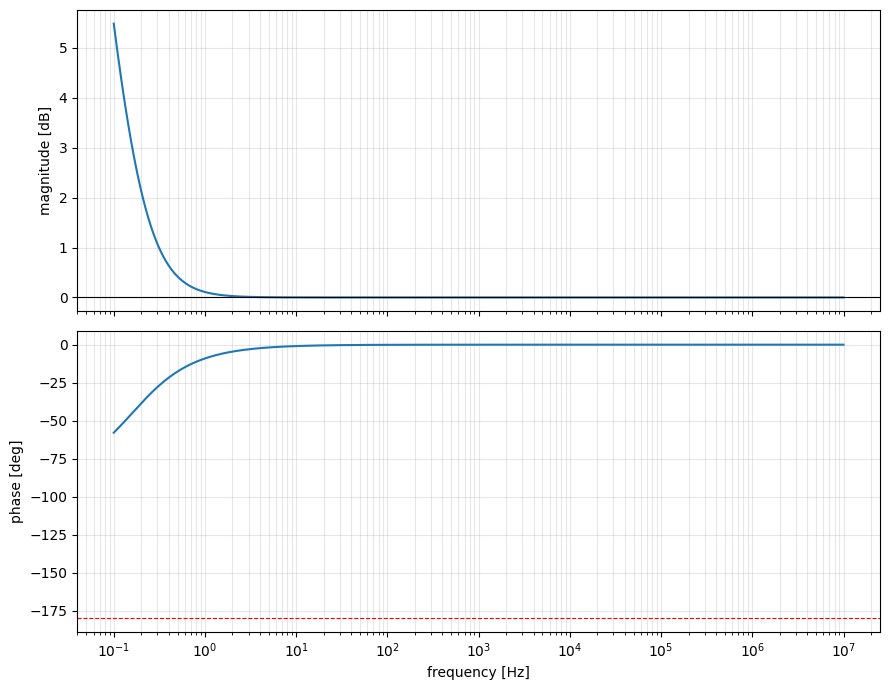

In [20]:
bode("(s+1)/s")

((s*0.2*10e-6 + 1) / (s*10e-6*(0.2+10)+1))*10
   crossover 1.58e+04 Hz, PM +106.9 deg


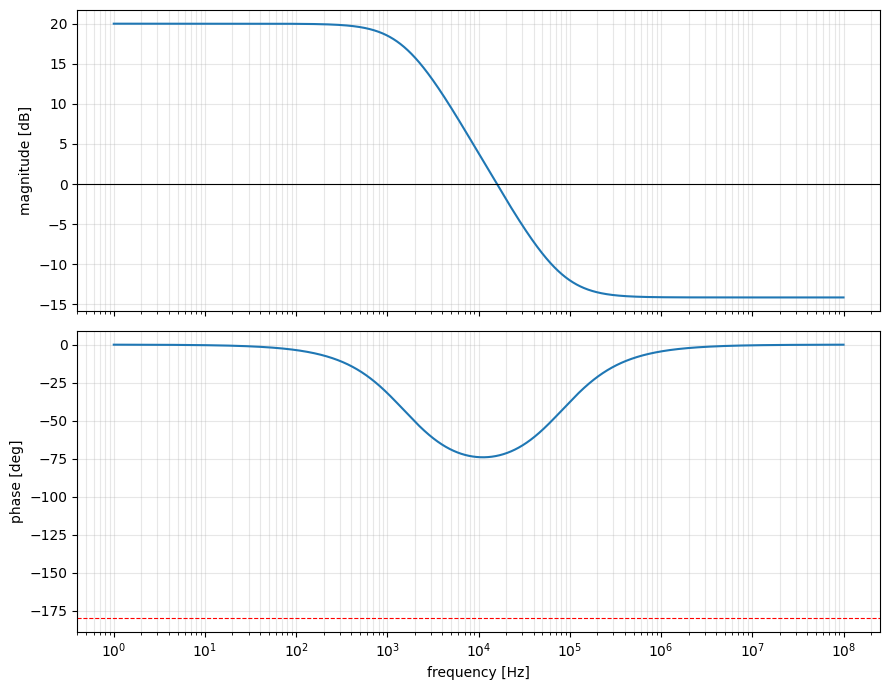

In [ ]:
# edit and re-run:
# Transfer function: of the output
bode("((s*0.2*10e-6 + 1) / (s*10e-6*(0.2+10)+1))*10", fmin=1, fmax=1e8)

I(16e3)*P(1.6e3)
   crossover 4.93e+03 Hz, PM +18.0 deg
I(16e3)*P(8e3)
   crossover 1e+04 Hz, PM +38.7 deg
I(16e3)*P(20e3)
   crossover 1.33e+04 Hz, PM +56.3 deg


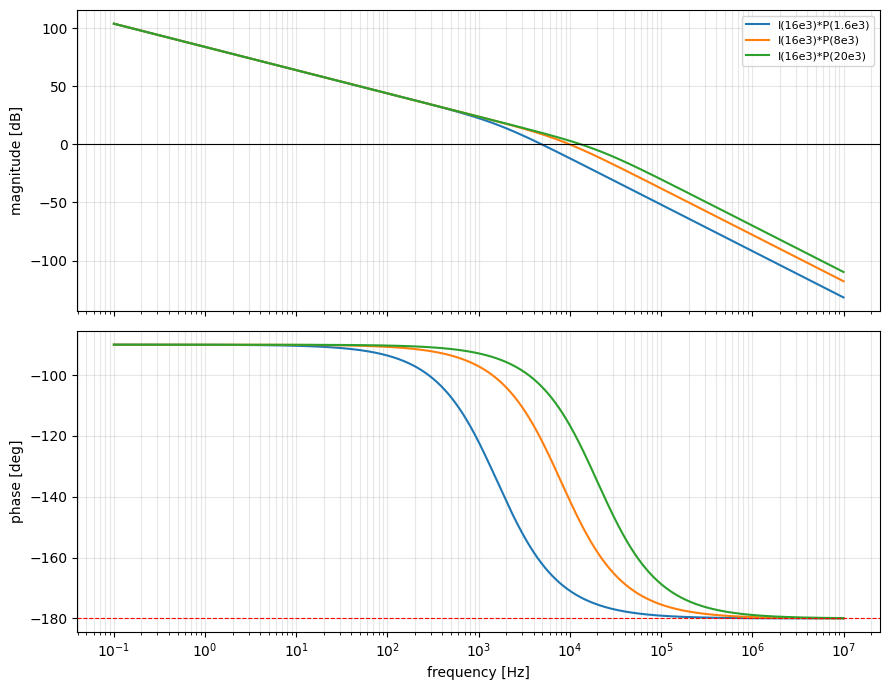

In [22]:
# overlay several at once:
bode(["I(16e3)*P(1.6e3)", "I(16e3)*P(8e3)", "I(16e3)*P(20e3)"])

## Optional: interactive text box
If `ipywidgets` is installed you get a live input box + frequency sliders. Otherwise just edit the cells above.

In [23]:
try:
    import ipywidgets as W
    box  = W.Text(value="100*I(16e3)*Z(159e3)*P(909)*P(1.6e3)",
                  description="H(s)=", layout=W.Layout(width="85%"))
    fmin = W.FloatLogSlider(value=0.1, base=10, min=-2, max=4, description="fmin Hz")
    fmax = W.FloatLogSlider(value=1e7, base=10, min=3, max=9, description="fmax Hz")
    W.interact_manual(lambda H, a, b: bode(H, a, b), H=box, a=fmin, b=fmax)
except ImportError:
    print("ipywidgets not installed -> just edit a bode(...) cell above and re-run.")

ipywidgets not installed -> just edit a bode(...) cell above and re-run.
